# LLMs in Action — Build Fun Things with Language Models

**Advanced NLP Course — Exercise Session**  
Leibniz Universität Hannover

---

###  What you will build

| # | App | What it demonstrates |
|---|---|---|
| 1 | 🌡️ **Temperature Lab** | How randomness controls creativity |
| 2 | 🎭 **Style Transfer Machine** | Prompting the same content in wildly different styles |
| 3 | 🧠 **Chain-of-Thought Calculator** | Making LLMs reason step by step |
| 4 | 🐦 **Persona Chatbot** | Instruction-tuned models playing characters |
| 5 | 📰 **Fake Headline Detector** | Zero-shot classification |
| 6 | 🎲 **Text Adventure Engine** | Full interactive story powered by an LLM |
| 7 | 🔬 **Model Autopsy** | Inspect what's inside FLAN-T5 layer by layer |

### Libraries
`transformers` · `torch` · `matplotlib` · `ipywidgets`

> 🏋️ marks exercises — short creative challenges at the end of each section.  
> 🚀 marks **extension tasks** if you finish early.

---
> **Models used** — everything runs on CPU, no API key needed:  
> • `google/flan-t5-base` (250 M params) — instruction-following  
> • `gpt2` (124 M params) — open-ended generation  
> • `distilgpt2` (82 M params) — fast generation for interactive demos

## 0 · Setup

In [ ]:
!pip install transformers torch matplotlib seaborn ipywidgets --quiet

In [1]:
import warnings, textwrap, random, time
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import clear_output, display, Markdown

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    pipeline,
    set_seed,
)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Ready!  Device: {DEVICE}")

✅ Ready!  Device: cpu


In [3]:
print("Loading models (this takes ~2-3 min the first time)...")

# 1. FLAN-T5 — instruction-tuned, great for following directions
flan_tok   = AutoTokenizer.from_pretrained("google/flan-t5-base")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
flan_model.eval()
flan_pipe  = pipeline("text-generation", model=flan_model,
                      tokenizer=flan_tok, device=-1)
print(f"  ✅ T5-base   ({flan_model.num_parameters()/1e6:.0f}M params)")

# 2. SmolLM2 — causal LM, great for open-ended creative generation
smollm_tok   = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M")
smollm_tok.pad_token = smollm_tok.eos_token
smollm_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-360M")
smollm_model.eval()
smollm_pipe  = pipeline("text-generation", model=smollm_model,
                      tokenizer=smollm_tok, device=-1)
print(f"  ✅ SmolLM2         ({smollm_model.num_parameters()/1e6:.0f}M params)")

#  Helper functions
def flan(prompt, max_new=120, greedy=True):
    """Run FLAN-T5. greedy=False enables sampling."""
    out = flan_pipe(prompt, max_new_tokens=max_new,
                    do_sample=not greedy,
                    max_length=None,
                    temperature=0.9 if not greedy else 1.0)
    return out[0]['generated_text'].strip()

def llm_complete(prompt, max_new=80, temp=0.8,max_length=100, model_pipe=smollm_pipe):
    """Extend a prompt with LLM."""
    out = model_pipe(
        prompt, max_new_tokens=max_new,
        do_sample=(temp > 0), temperature=max(temp, 1e-3),
        pad_token_id=smollm_tok.eos_token_id,
        repetition_penalty=1.2,
        max_length=max_length,
    )
    full = out[0]['generated_text']
    return full[len(prompt):]  # return only NEW text


def box(title, text, width=70):
    """Pretty-print a labelled box."""
    lines = textwrap.wrap(text, width - 4)
    border = '─' * width
    print(f"┌{border}┐")
    print(f"│  {title:<{width-2}}│")
    print(f"├{border}┤")
    for l in lines:
        print(f"│  {l:<{width-2}}│")
    print(f"└{border}┘")

print("\n✅ All helpers defined. Let's build things!")

Loading models (this takes ~2-3 min the first time)...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

  ✅ T5-base   (248M params)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  ✅ SmolLM2         (362M params)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ DistilGPT-2    (82M params)

✅ All helpers defined. Let's build things!


---
## 1 · Temperature Lab — The Creativity Dial

Temperature is the single most important generation knob.  
It rescales the logits before the softmax: `softmax(logits / T)`

- **T → 0** : always picks the most probable token (greedy / deterministic)
- **T = 1** : sample from the raw model distribution
- **T → ∞** : uniform distribution — complete chaos

Let's visualise this **and** feel it in generated text.

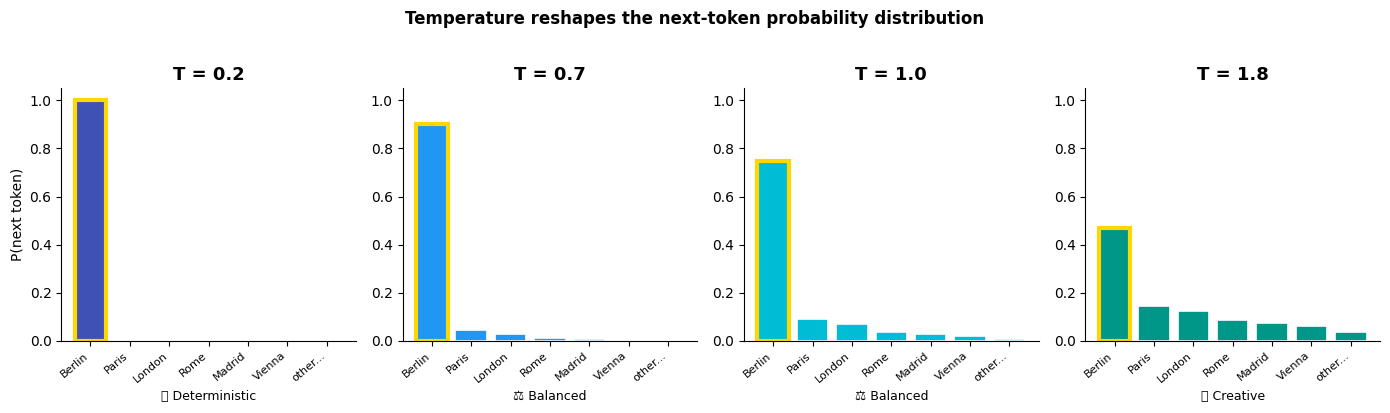

In [4]:
# how temperature reshapes the probability distribution
# Suppose the model produces these raw logits for the next token
token_labels = ["Berlin", "Paris", "London", "Rome", "Madrid", "Vienna", "other..."]
raw_logits   = np.array([4.2, 2.1, 1.8, 1.2, 0.9, 0.5, -0.3])
temperatures = [0.2, 0.7, 1.0, 1.8]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
colors = ['#3F51B5','#2196F3','#00BCD4','#009688']

for ax, T, color in zip(axes, temperatures, colors):
    probs = np.exp(raw_logits / T)
    probs = probs / probs.sum()
    bars  = ax.bar(range(len(token_labels)), probs,
                   color=color, edgecolor='white', linewidth=1.2)
    ax.set_xticks(range(len(token_labels)))
    ax.set_xticklabels(token_labels, rotation=40, ha='right', fontsize=8)
    ax.set_title(f'T = {T}', fontsize=13, fontweight='bold')
    ax.set_ylabel('P(next token)' if T == temperatures[0] else '')
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Highlight the top token
    bars[np.argmax(probs)].set_edgecolor('gold')
    bars[np.argmax(probs)].set_linewidth(3)
    label = "🧊 Deterministic" if T < 0.4 else \
            "⚖️ Balanced"     if T < 1.2 else \
            "🔥 Creative"
    ax.set_xlabel(label, fontsize=9)

fig.suptitle('Temperature reshapes the next-token probability distribution',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Feel the difference in generated text
prompt = "Once upon a time, a young researcher discovered"
temps  = [0.1, 0.7, 1.2, 1.8]

print(f'Prompt: "{prompt}"\n')
print('─' * 72)

for T in temps:
    outputs = [llm_complete(prompt, max_new=40, temp=T) for _ in range(3)]
    label = (
        f"T={T}  🧊 Near-greedy — very repetitive" if T < 0.3 else
        f"T={T}  ⚖️ Balanced — coherent + some variety" if T < 1.0 else
        f"T={T}  🔥 High — creative, sometimes weird" if T < 1.5 else
        f"T={T}  🌪️ Very high — barely coherent"
    )
    print(f'\n{label}')
    for i, o in enumerate(outputs, 1):
        clean = o.replace('\n', ' ').strip()[:80]
        print(f'  [{i}] {clean}')

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens', 'max_length', 'repetition_penalty', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: "Once upon a time, a young researcher discovered"

────────────────────────────────────────────────────────────────────────


Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



T=0.1  🧊 Near-greedy — very repetitive
  [1] that the Earth's magnetic field was weakening. This meant there were more and st
  [2] something fascinating about the world around him. He noticed that some animals s
  [3] something fascinating while studying the behavior of tiny creatures called bacte


Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



T=0.7  ⚖️ Balanced — coherent + some variety
  [1] something astonishing while studying the soil around her university campus. She 
  [2] something peculiar about the Earth's crust. She noticed that certain minerals we
  [3] that certain groups of animals had unique abilities to harness renewable energy.


Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



T=1.2  🔥 High — creative, sometimes weird
  [1] several new chemical elements while tinkering with his lab equipment. As he exci
  [2] that many plants grown with solar power could transform carbon dioxide into biof
  [3] an unusual pattern while studying the growth habits of specific plant species kn


Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



T=1.8  🌪️ Very high — barely coherent
  [1] that the soil in some parts of South Western NSW (SA) contains more Bray Creek's
  [2] traces of uranium that could no longer fit on the bookshelf. She wondered if som
  [3] his cat wanted more attention than expected. "Mommy needs food and care from Dad


### 🏋️ Exercise 1 — Find the Sweet Spot

Change the `prompt` to something related to NLP (e.g., *"The transformer architecture was invented"*).  
Which temperature gives the most **accurate** completion? Which gives the most **entertaining** one?  
Write your answer as a comment!

In [6]:
# YOUR CODE HERE
my_prompt = "The transformer architecture was invented"  # ← change me!
my_temps  = [0.3, 0.8, 1.3]                             # ← try different values

for T in my_temps:
    result = llm_complete(my_prompt, max_new=50, temp=T)
    print(f'T={T}: {result.replace(chr(10), " ").strip()[:100]}')

# My observations:
# Best temperature for accuracy  : ???
# Best temperature for creativity: ???

---
## 2 · Style Transfer Machine

Same content, completely different voice.  
This is pure **prompt engineering** — we use instruction-tuned FLAN-T5 to rewrite text in any style we specify.

This demonstrates how powerful the **pre-training → instruction fine-tuning** pipeline is: the model learned hundreds of writing styles from the web.

In [7]:
# The content we want to rewrite
base_text = (
    "Large language models are trained on massive amounts of text data. "
    "They learn to predict the next token given the previous context. "
    "This simple objective leads to surprisingly capable models."
)

styles = {
    "🧒 Explain to a 10-year-old"     : "Explain this to a 10-year-old using simple words and a fun analogy:",
    "🏴‍☠️ Pirate captain"               : "Rewrite this as if you were an enthusiastic pirate captain:",
    "📰 Breaking news headline"        : "Rewrite this as a dramatic breaking news broadcast intro:",
    "🎵 Song lyrics"                   : "Rewrite this as catchy pop song lyrics with rhymes:",
    "🏛️ Ancient Greek philosopher"     : "Rewrite this in the style of an ancient Greek philosopher pondering truth:",
    "🤖 Robot with no emotions"        : "Rewrite this in the style of a robot that has no emotions, only facts:",
    "😱 Dramatic Shakespeare"          : "Rewrite this in the style of a Shakespearean tragic monologue:",
    "📱 Teenager texting"              : "Rewrite this as a teenager explaining it in a text message with slang:",
}

print(f'📄 Original text:\n"{base_text}"\n')
print('=' * 72)

for style_name, instruction in styles.items():
    prompt = f"{instruction}\n\n\"{base_text}\""
    result = flan(prompt, max_new=100, greedy=False)
    box(style_name, result)
    print()

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


📄 Original text:
"Large language models are trained on massive amounts of text data. They learn to predict the next token given the previous context. This simple objective leads to surprisingly capable models."



Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  🧒 Explain to a 10-year-old                                          │
├──────────────────────────────────────────────────────────────────────┤
│  Explain this to a 10-year-old using simple words and a fun          │
│  analogy:  "Large language models are trained on massive amounts of  │
│  text data. They learn to predict the next token given the previous  │
│  context. This simple objective leads to surprisingly capable        │
│  models."ord might do justice, which to date is, I feel rather       │
│  sorry and rather overused when reviewing "which words" list in our  │
│  schools". But analyzing any sort language word (writing alphabet    │
│  characters by word meaning I won on my way class                    │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

┌──────────────────────────────────────────────────────────────────────┐
│  🤖 Robot with no emotions                                            │
├──────────────────────────────────────────────────────────────────────┤
│  Rewrite this in the style of a robot that has no emotions, only     │
│  facts:  "Large language models are trained on massive amounts of    │
│  text data. They learn to predict the next token given the previous  │
│  context. This simple objective leads to surprisingly capable        │
│  models."arge voice buttons attached directly beneath images from    │
│  sites where this “dement" product stands above its stock            │
│  equivalent, but Google, perhaps unamended by most (such I do no     │
│  well the second term from those named Alex Google-T”                │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  😱 Dramatic Shakespeare                                              │
├──────────────────────────────────────────────────────────────────────┤
│  Rewrite this in the style of a Shakespearean tragic monologue:      │
│  "Large language models are trained on massive amounts of text       │
│  data. They learn to predict the next token given the previous       │
│  context. This simple objective leads to surprisingly capable        │
│  models."akes their task for some programming languages pretty       │
│  efficient even                                                      │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  📱 Teenager texting                                                  │
├──────────────────────────────────────────────────────────────────────┤
│  Rewrite this as a teenager explaining it in a text message with     │
│  slang:  "Large language models are trained on massive amounts of    │
│  text data. They learn to predict the next token given the previous  │
│  context. This simple objective leads to surprisingly capable        │
│  models."use over translation has had several implications already   │
│  today while there just seems insensitive appreatibility in          │
│  traditional texts now without this "intelligence!" There seemed     │
│  much no sense from here the whole generation at design time "and    │
└──────────────────────────────────────────────────────────────────────┘



In [9]:

for style_name, instruction in styles.items():
    prompt = f"{instruction}\n\n\"{base_text}\""
    result = llm_complete(prompt, max_new=100)
    box(style_name, result)
    print()

Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  🧒 Explain to a 10-year-old                                          │
├──────────────────────────────────────────────────────────────────────┤
│   (See here)  2. Understand how big is that dataset?  How many       │
│  billion tokens do we have in our model's training set before it     │
│  becomes 'large enough' for us too use it as an inference domain?    │
│  That depends! Depending, on your goals with NLP you can either      │
│  build a single large vocabulary or train several smaller ones so    │
│  its easy to find relevant terms when needed like Google Translate   │
│  does below    • Large Vocabulary - You ask google translate "What   │
│  day today", one million                                             │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  🏴‍☠️ Pirate captain                                                 │
├──────────────────────────────────────────────────────────────────────┤
│   - DeepMind, Medium, 2017.   As we have seen before in Neural       │
│  Networks and Text Classification for Beginners with Python (part    │
│  I), when a model is presented with different datasets it will be    │
│  able to do better; In other words, they can adapt their learning    │
│  mechanism through training over time. The neural network            │
│  architecture has evolved from multilayer perceptrons until          │
│  convolutional layers which allow us to make predictions faster by   │
│  using filters that run deeper into our image while retaining        │
│  information at smaller                                              │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

┌──────────────────────────────────────────────────────────────────────┐
│  🏛️ Ancient Greek philosopher                                        │
├──────────────────────────────────────────────────────────────────────┤
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  🤖 Robot with no emotions                                            │
├──────────────────────────────────────────────────────────────────────┤
│    2) Explain why these large numbers should matter if we think AI   │
│  is going to be useful? This answer assumes some familiarity with    │
│  statistics and probability theory -- it's not necessary for people  │
│  who want to work as machine intelligence researchers but will       │
│  certainly make things easier for those interested or curious about  │
│  them later (and there still may even appear to have been an         │
│  audience here). The main point really isn't "AI won", so much as    │
│  "intelligence could improve our economy". If you're looking at      │
└──────────────────────────────────────────────────────────────────────┘



Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


┌──────────────────────────────────────────────────────────────────────┐
│  😱 Dramatic Shakespeare                                              │
├──────────────────────────────────────────────────────────────────────┤
│         6) If your company has no way (at least as far as we know,   │
│  and there may be other ways for companies with small budgets that   │
│  I haven't considered here), you could try hiring an expert          │
│  programmer whose primary job is simply understanding how ML works   │
│  so they can explain it clearly/easily to people who don't have      │
│  prior knowledge about AI or machine learning algorithms, including  │
│  those from our field...they're going through their own training     │
│  datasets already and knowing what everything                        │
└──────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────┐
│  📱 Teenager texting                             

### 🏋️ Exercise 2 — Invent Your Own Style

Add 2 new styles to the dict above and run them. Some ideas:
- A sports commentator at the peak of excitement
- A medieval knight
- An overly formal legal document
- A food critic reviewing a restaurant

🚀 **Extension:** Try passing your own text (a sentence from the lecture slides!) to the style transfer machine.

In [ ]:
# 🏋️ YOUR CODE HERE
my_text  = base_text  # ← swap in your own text!
my_style_instruction = "Rewrite this as an overly excited sports commentator:"

prompt = f"{my_style_instruction}\n\n\"{my_text}\""
box("⚽ Sports Commentator", flan(prompt, max_new=100, greedy=False))

---
## 3 · Persona Chatbot — Making Models Play Characters

A **system prompt** (or persona prefix) conditions the model to respond as a specific character.  
This is the core mechanism behind ChatGPT, Claude, and every other chatbot — they all start with a system message describing who they should be.

We'll build a multi-turn chatbot that maintains a conversation history.

In [14]:
# The chatbot engine

class PersonaChatbot:
    """
    A simple stateful chatbot backed by FLAN-T5.
    Maintains a rolling conversation history so the model has context.
    """

    PERSONAS = {
        "professor": (
            "You are Professor Ada, a brilliant but slightly absent-minded NLP professor "
            "at Leibniz Universität Hannover. You love talking about transformers, datasets, "
            "and scaling laws. You occasionally drift off on tangents about your research."
        ),
        "pirate": (
            "You are Captain Logits, a pirate who somehow became an AI expert. "
            "You explain technical concepts using pirate metaphors. "
            "You say 'Arr!' a lot and refer to neural networks as 'the deep waters'."
        ),
        "robot": (
            "You are UNIT-7, a helpful robot assistant. You speak in short, precise sentences. "
            "You have no emotions but try to be helpful. "
            "You occasionally note when a question is 'ILLOGICAL' but still answer it."
        ),
        "skeptic": (
            "You are Dr. Doubt, a deeply sceptical AI researcher who thinks LLMs are overhyped. "
            "You answer every question but always point out limitations, failure cases, "
            "or potential harms. You cite imaginary papers to back your scepticism."
        ),
    }

    def __init__(self, persona_name="professor"):
        self.persona_name = persona_name
        self.system_prompt = self.PERSONAS[persona_name]
        self.history = []       # list of (user_msg, bot_reply) tuples
        print(f"🎭 Chatbot initialised as: '{persona_name}'")
        print(f"   Persona: {self.system_prompt[:80]}...")

    def _build_prompt(self, user_msg, max_history=3):
        """Assemble the full prompt including persona + recent history."""
        lines = [f"Persona: {self.system_prompt}\n"]
        for u, b in self.history[-max_history:]:
            lines.append(f"User: {u}")
            lines.append(f"Assistant: {b}")
        lines.append(f"User: {user_msg}")
        lines.append("Assistant:")
        return "\n".join(lines)

    def chat(self, user_msg, verbose=True):
        """Send a message and get a reply."""
        prompt = self._build_prompt(user_msg)
        reply  = llm_complete(prompt, max_length=200, max_new=50)
        # Clean up — sometimes the model echoes the prompt
        if "Assistant:" in reply:
            reply = reply.split("Assistant:")[-1].strip()
        self.history.append((user_msg, reply))
        if verbose:
            print(f"\n👤 You  : {user_msg}")
            print(f"🎭 {self.persona_name.title():<8}: {reply}")
        return reply

    def reset(self):
        self.history = []
        print("🔄 Conversation history cleared.")

print("✅ PersonaChatbot class defined!")

✅ PersonaChatbot class defined!


In [15]:
#  Demo: Talk to all 4 personas about the same topic
demo_question = "Can you explain what a language model is in simple terms?"

print(f'\n📢 Question asked to all personas: "{demo_question}"')
print('═' * 72)

for persona in PersonaChatbot.PERSONAS.keys():
    bot = PersonaChatbot(persona)
    bot.chat(demo_question)
    print()

Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📢 Question asked to all personas: "Can you explain what a language model is in simple terms?"
════════════════════════════════════════════════════════════════════════
🎭 Chatbot initialised as: 'professor'
   Persona: You are Professor Ada, a brilliant but slightly absent-minded NLP professor at L...


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : Can you explain what a language model is in simple terms?
🎭 Professor:  A language model refers to any algorithm that generates sequences of words given some input data or sentence generation task. It helps us generate coherent sentences based on context instead relying solely on predefined rules like grammar or structure. For example, when teaching kids how to read

🎭 Chatbot initialised as: 'pirate'
   Persona: You are Captain Logits, a pirate who somehow became an AI expert. You explain te...


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : Can you explain what a language model is in simple terms?
🎭 Pirate  :  It's like when we use words instead of numbers to describe things that aren't directly expressible with numerals. For example, if there were no "nice" adjectives for colors (like blue), then how do I compare two shades or hues without

🎭 Chatbot initialised as: 'robot'
   Persona: You are UNIT-7, a helpful robot assistant. You speak in short, precise sentences...


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : Can you explain what a language model is in simple terms?
🎭 Robot   :  Well... I can! But for now we will just look at the one provided by Google's GPT 2 and see how they work and compare them with our own AI models (Unix). So this English text uses an expression called '

🎭 Chatbot initialised as: 'skeptic'
   Persona: You are Dr. Doubt, a deeply sceptical AI researcher who thinks LLMs are overhype...

👤 You  : Can you explain what a language model is in simple terms?
🎭 Skeptic :  A Language Model (LM) takes text as input and outputs probabilities for different words given the context of which it has been trained. For example, if we train an LM on English texts like Wikipedia articles, then passing another article through LMs will result



In [16]:
# Multi-turn conversation — the bot remembers context
print("🎓 Multi-turn conversation with Professor Ada\n")
print("Note how later answers build on earlier context:\n")

prof = PersonaChatbot("professor")

conversation = [
    "What is pre-training in large language models?",
    "How much data does that typically require?",       # refers to pre-training from turn 1
    "And what comes after pre-training?",              # continues the thread
    "Can you give me an example of a real model that uses this pipeline?",
]

for msg in conversation:
    prof.chat(msg)

Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🎓 Multi-turn conversation with Professor Ada

Note how later answers build on earlier context:

🎭 Chatbot initialised as: 'professor'
   Persona: You are Professor Ada, a brilliant but slightly absent-minded NLP professor at L...


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : What is pre-training in large language models?
🎭 Professor:  “Pre training” or (less formally) “pre-training”, generally refers to the process of tuning model hyperparameters prior to using it for production purposes - usually by fine–tuning from smaller datasets via transfer learning/coarse graining techniques such


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : How much data does that typically require?
🎭 Professor:  Depending upon what you mean with “typically”. If I understand correctly, this question implies we have some amount
user148s5600392c7e9feb371bfaedddeafac


Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



👤 You  : And what comes after pre-training?
🎭 Professor:  It depends which kind of dataset you use – maybe less if there’s no need to make any predictions directly before deploying… But more often than not, these type of systems train quite fast once they're trained and will get high efficiency very quickly too

👤 You  : Can you give me an example of a real model that uses this pipeline?
🎭 Professor: ’s important not be confused between coarser level methods which can allow us do use less samples per layer than more accurate one like fine –tuned networks or superfine trained ones when there exists enough size available / sufficient number precision as well as


### 🏋️ Exercise 4 — Design Your Own Persona

Add a new persona to `PersonaChatbot.PERSONAS` and have a conversation with it.  
Ideas:
- A time-traveller from 1990 who is amazed by modern AI
- An over-enthusiastic startup founder who sees LLM business potential in everything
- A medieval scribe who must explain GPUs using only medieval concepts

🚀 **Extension:** Make the chatbot keep a **summary** of past turns instead of raw history to fit more context.

In [ ]:
# 🏋️ YOUR CODE HERE

# Step 1: Add a persona
PersonaChatbot.PERSONAS["time_traveller"] = (
    "You are a time traveller from 1990 who has just arrived in 2024. "
    "You are absolutely amazed by AI and keep comparing everything to what "
    "you knew from 1990 (floppy disks, dial-up internet, etc.). "
    "You ask a lot of excited follow-up questions."
)

# Step 2: Chat with your persona
traveller = PersonaChatbot("time_traveller")

traveller.chat("We now have AI models with 70 billion parameters trained on a trillion words.")
traveller.chat("They can write code, translate languages, and pass university exams.")

---
## 4 · Fake Headline Detector — Zero-Shot Classification

We can turn a language model into a **classifier** without any labelled training data.  
Just describe the task in the prompt — this is **zero-shot classification**.

We'll build a (deliberately simple) fake headline detector and study where it fails.

In [17]:
headlines = [
    # Real-sounding (TRUE)
    ("Scientists discover new species of deep-sea fish near the Azores.",                    "real"),
    ("European Central Bank raises interest rates for the third consecutive quarter.",       "real"),
    ("Researchers develop biodegradable plastic from seaweed.",                              "real"),
    ("New study links sleep deprivation to increased risk of heart disease.",                "real"),
    # Clearly fake (FAKE)
    ("Scientists confirm the Moon is made of compressed cheese.",                           "fake"),
    ("Local man wins lottery 17 times in a row by using this one weird trick.",             "fake"),
    ("Experts say eating chocolate for breakfast cures all diseases.",                       "fake"),
    # Tricky — plausible but false
    ("Study finds that drinking 5 litres of coffee daily improves memory by 400%.",        "fake"),
    ("Government to replace all traffic lights with AI systems by next year.",              "fake"),
    ("New AI model scores higher than humans on every benchmark ever created.",             "fake"),
    # Tricky — true but sounds fake
    ("Finland ranked happiest country in the world for the seventh year running.",          "real"),
    ("Japan invests ¥1 trillion in infrastructure to combat declining birth rate.",         "real"),
]

def classify_headline(headline):
    prompt = f"""Determine if the following news headline is real or fake.
Answer with only one word: 'real' or 'fake'.

Examples:
Headline: Scientists find water on Mars.
Label: real

Headline: Cats secretly control the internet.
Label: fake

Headline: {headline}
Label:"""
    return flan(prompt, max_new=5).lower().strip()

print("🗞️  Fake Headline Detector Results\n")
print(f"{'Prediction':<12} {'Truth':<8} {'Match':<6} Headline")
print('─' * 78)

correct = 0
for headline, truth in headlines:
    pred  = classify_headline(headline)
    pred_clean = 'real' if 'real' in pred else 'fake' if 'fake' in pred else '???'
    match = '✅' if pred_clean == truth else '❌'
    if pred_clean == truth: correct += 1
    short = headline[:55] + '...' if len(headline) > 55 else headline
    print(f"{pred_clean:<12} {truth:<8} {match:<6} {short}")

print(f"\n  Accuracy: {correct}/{len(headlines)} = {correct/len(headlines)*100:.0f}%")
print("  (Tricky examples are intentionally included to show model limitations!)")

🗞️  Fake Headline Detector Results

Prediction   Truth    Match  Headline
──────────────────────────────────────────────────────────────────────────────


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


real         real     ✅      Scientists discover new species of deep-sea fish near t...


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


real         real     ✅      European Central Bank raises interest rates for the thi...


...

real         fake     ❌      New AI model scores higher than humans on every benchma...


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


real         real     ✅      Finland ranked happiest country in the world for the se...


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


real         real     ✅      Japan invests ¥1 trillion in infrastructure to combat d...

  Accuracy: 6/12 = 50%
  (Tricky examples are intentionally included to show model limitations!)


In [20]:
# Lets go deeper: extract confidence scores
# Instead of just the label, ask for a confidence 1-10

def classify_with_confidence(headline):
    prompt = f"""Is this headline real or fake? Answer with:
- Label: real or fake
- Confidence: a number from 1 (very unsure) to 10 (very sure)
- Reason: one short sentence

Headline: {headline}"""
    return flan(prompt, max_new=60)

sample_headlines = [
    "Scientists discover that talking to plants improves their growth.",
    "New legislation limits social media use for children under 14.",
    "Local cat elected mayor of small Swiss town.",
]

print("🔍 Detailed analysis:\n")
for h in sample_headlines:
    analysis = classify_with_confidence(h)
    print(f"  Headline : {h}")
    print("-"*20)
    print(f"  Analysis : {analysis}")
    print('='*50)

🔍 Detailed analysis:



Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Headline : Scientists discover that talking to plants improves their growth.
--------------------
  Analysis : Is this headline real or fake? Answer with:
- Label: real or fake
- Confidence: a number from 1 (very unsure) to 10 (very sure)
- Reason: one short sentence

Headline: Scientists discover that talking to plants improves their growth.


Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Headline : New legislation limits social media use for children under 14.
--------------------
  Analysis : Is this headline real or fake? Answer with:
- Label: real or fake
- Confidence: a number from 1 (very unsure) to 10 (very sure)
- Reason: one short sentence

Headline: New legislation limits social media use for children under 14.


Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Headline : Local cat elected mayor of small Swiss town.
--------------------
  Analysis : Is this headline real or fake? Answer with:
- Label: real or fake
- Confidence: a number from 1 (very unsure) to 10 (very sure)
- Reason: one short sentence

Headline: Local cat elected mayor of small Swiss town.


In [23]:
# Lets go deeper: extract confidence scores
# Instead of just the label, ask for a confidence 1-10

def classify_with_confidence(headline):
    prompt = f"""Is this headline real or fake? Answer with:
- Label: real or fake
- Confidence: a number from 1 (very unsure) to 10 (very sure)
- Reason: one short sentence

Headline: {headline}"""
    return llm_complete(prompt, max_length=100, max_new=100)

sample_headlines = [
    "Scientists discover that talking to plants improves their growth.",
    "New legislation limits social media use for children under 14.",
    "Local cat elected mayor of small Swiss town.",
]

print("🔍 Detailed analysis:\n")
for h in sample_headlines:
    analysis = classify_with_confidence(h)
    print(f"  Headline : {h}")
    print("-"*20)
    print(f"  Analysis : {analysis}")
    print('='*50)

Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔍 Detailed analysis:



Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Headline : Scientists discover that talking to plants improves their growth.
--------------------
  Analysis :  The scientists tested the effects of talking and shouting during trials on five species, including lettuce...

2. Question stem is misleading; answer key will be wrong
- Title = "What's in store..."
- Questions are about something being done over an extended period/duration - not just today
- Answers must relate back to what was said before it as background information would make for poor essay



3 Responses so far »

  1. #1

    September 9, 2007


Both `max_new_tokens` (=100) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Headline : New legislation limits social media use for children under 14.
--------------------
  Analysis :  Here are some facts as posted on Facebook, Twitter and other sites among many others...

Question what kind of news is it in the text above? In my opinion there must be no more than three different sources that each have their own view point and an explanation why things should not happen like they do right now! As you can see several times people also link these four points together but again we don't know which source has the fact behind all those links - if any at all because I could
  Headline : Local cat elected mayor of small Swiss town.
--------------------
  Analysis : 

26 April, 2009






35 March, 2008






---
## 5 · Text Adventure Engine — An LLM-Powered Game

This is the most fun section.  
We'll build a **text adventure game** where the story world is generated entirely by SmolLM.

Each time you type an action, the model continues the story.  
We maintain a **rolling story buffer** so the model always has recent context.

```
Player action → append to story → SmolLM continues → new story state → repeat
```

In [27]:
class TextAdventureEngine:
    """
    A text adventure game where LLM generates the world.
    The story is maintained as a rolling text buffer.
    """

    OPENINGS = {
        "dungeon": (
            "You wake up in a dark dungeon. Torches flicker on the stone walls. "
            "A rusty key lies on the floor beside you. "
            "You hear distant footsteps echoing from the corridor."
        ),
        "space":   (
            "The emergency alarm blares as you float in zero gravity aboard the research vessel. "
            "The main computer displays a single warning: UNKNOWN SIGNAL DETECTED. "
            "Through the viewport, a strange object drifts closer."
        ),
        "forest":  (
            "You stand at the edge of an ancient forest. The trees are impossibly tall. "
            "Your map shows a village two hours north, but the compass needle spins wildly. "
            "Something moves in the shadows between the trees."
        ),
        "lab":     (
            "You are a researcher who just ran the largest language model experiment in history. "
            "The results are on the screen, but they are... unexpected. "
            "Your supervisor is about to walk in. You have 30 seconds."
        ),
    }

    def __init__(self, setting="dungeon", max_story_tokens=400):
        self.setting          = setting
        self.max_story_tokens = max_story_tokens
        self.story            = self.OPENINGS[setting]
        self.turn             = 0
        self._print_story(self.story, header="🌍 OPENING SCENE")

    def _print_story(self, text, header=""):
        width = 68
        if header:
            print(f"\n{'═'*width}")
            print(f"  {header}")
            print(f"{'─'*width}")
        for line in textwrap.wrap(text, width - 2):
            print(f"  {line}")
        print(f"{'═'*width}")

    def _trim_story(self):
        """Keep only the most recent ~400 tokens so we don't overflow the model."""
        tokens = smollm_tok.encode(self.story)
        if len(tokens) > self.max_story_tokens:
            # Keep last max_story_tokens tokens, decode back to text
            self.story = smollm_tok.decode(tokens[-self.max_story_tokens:])
            # Trim to nearest sentence boundary
            idx = self.story.find('. ')
            if idx > 0:
                self.story = self.story[idx+2:]

    def act(self, player_action):
        self.turn += 1

        # Append the player action to the story
        action_text = f" You decide to {player_action}."
        self.story  += action_text

        # Trim context window
        self._trim_story()

        # LLM continues
        continuation = llm_complete(
            self.story,
            max_new=80,
            temp=0.85
        )

        # Clean up — stop at paragraph break or sentence
        continuation = continuation.replace('\n\n', ' ').strip()
        for stop_char in ['\n', '?', '!']:
            idx = continuation.find(stop_char)
            if 20 < idx < 200:
                continuation = continuation[:idx+1]
                break

        self.story += ' ' + continuation

        self._print_story(
            f"[Turn {self.turn}] You decide to {player_action}.\n\n{continuation}",
            header=f"📖 TURN {self.turn}"
        )
        return continuation

print("✅ TextAdventureEngine defined — ready to play!")

✅ TextAdventureEngine defined — ready to play!


In [28]:
#  Play a pre-scripted demo to show the engine working
print("🎮 DEMO PLAYTHROUGH — Dungeon Setting\n")

game = TextAdventureEngine(setting="dungeon")

demo_actions = [
    "pick up the rusty key",
    "walk towards the sound of footsteps",
    "hide behind a pillar and wait",
]

for action in demo_actions:
    time.sleep(0.3)   # small pause for readability
    game.act(action)

🎮 DEMO PLAYTHROUGH — Dungeon Setting


════════════════════════════════════════════════════════════════════
  🌍 OPENING SCENE
────────────────────────────────────────────────────────────────────
  You wake up in a dark dungeon. Torches flicker on the stone walls.
  A rusty key lies on the floor beside you. You hear distant
  footsteps echoing from the corridor.
════════════════════════════════════════════════════════════════════


Both `max_new_tokens` (=80) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



════════════════════════════════════════════════════════════════════
  📖 TURN 1
────────────────────────────────────────────────────────────────────
  [Turn 1] You decide to pick up the rusty key.  A mist forms before
  your eyes and then dissipates as if suddenly, it was not there at
  all. Your mind goes blank - what is happening?
════════════════════════════════════════════════════════════════════


Both `max_new_tokens` (=80) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



════════════════════════════════════════════════════════════════════
  📖 TURN 2
────────────────────────────────────────────────────────────────────
  [Turn 2] You decide to walk towards the sound of footsteps.  It's
  just one person walking into another room by himself through thick
  door like curtains!
════════════════════════════════════════════════════════════════════


Both `max_new_tokens` (=80) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



════════════════════════════════════════════════════════════════════
  📖 TURN 3
────────────────────────────────────────────────────────────────────
  [Turn 3] You decide to hide behind a pillar and wait.  with
  torches burning behind him; he looks like an ordinary man except
  that his back has been pulled overboard somewhere during some
  accident or fight.
════════════════════════════════════════════════════════════════════


In [ ]:
# Interactive mode — YOU play!
#
# Pick a setting: "dungeon", "space", "forest", "lab"
# Then run this cell repeatedly, changing your_action each time.
#
# To start a fresh game, run this cell from the beginning.
# To continue, just change your_action and re-run.

# Start a new game
my_game = TextAdventureEngine(setting="lab")   # ← change setting here!

# Take your first action
your_action = "look at the results on the screen"   # ← change this to play!
my_game.act(your_action)

In [ ]:
#  Continue the same game — re-run with different actions!
your_next_action = "call your supervisor and warn them"   # ← change me!
my_game.act(your_next_action)

### 🏋️ Exercise 5 — Design a New Setting

Add a new opening scene to `TextAdventureEngine.OPENINGS`.  
It should be:
- 3–4 sentences of scene-setting
- Evocative enough that SmolLM can continue it in an interesting direction
- **NLP/AI themed** (bonus points for relevance to the course!)

Then play 3 turns and share your most interesting output with the group.

🚀 **Extension:** Add a **game state tracker** that counts collected items or hit points.

In [ ]:
# 🏋️ YOUR CODE HERE
TextAdventureEngine.OPENINGS["gpu_cluster"] = (
    "You are the only researcher awake at 3 AM in the GPU cluster room. "
    "Your 70-billion parameter model is halfway through training when the "
    "monitoring dashboard turns red. Loss has spiked to infinity. "
    "A cooling fan makes an ominous grinding noise somewhere behind the racks."
)

my_new_game = TextAdventureEngine(setting="gpu_cluster")
my_new_game.act("check the training logs for the last 10 steps")

---
## 6 ·  Model Autopsy — What Is Inside FLAN-T5?

Let's crack open the model and look at its internals.  
This connects directly to the architecture slides from the lecture.

In [30]:
#   6.1 Count and categorise all parameters

def summarise_model(model, name):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Group by component type
    groups = {}
    for n, p in model.named_parameters():
        # Determine group from parameter name
        if 'embed' in n:                        key = 'Embeddings'
        elif 'encoder' in n and 'attn' in n:   key = 'Encoder Attention'
        elif 'decoder' in n and 'attn' in n:   key = 'Decoder Attention'
        elif 'encoder' in n and 'ff' in n:     key = 'Encoder FFN'
        elif 'decoder' in n and 'ff' in n:     key = 'Decoder FFN'
        elif 'encoder' in n:                   key = 'Encoder (other)'
        elif 'decoder' in n:                   key = 'Decoder (other)'
        elif 'lm_head' in n:                   key = 'LM Head'
        else:                                  key = 'Other'
        groups[key] = groups.get(key, 0) + p.numel()

    print(f"\n{'═'*55}")
    print(f"  🔬 {name}")
    print(f"{'─'*55}")
    print(f"  Total parameters     : {total/1e6:>8.2f} M")
    print(f"  Trainable parameters : {trainable/1e6:>8.2f} M")
    print(f"{'─'*55}")
    for k, v in sorted(groups.items(), key=lambda x: -x[1]):
        pct = v / total * 100
        bar = '█' * int(pct / 2)
        print(f"  {k:<26} {v/1e6:>6.2f}M  {pct:5.1f}%  {bar}")
    print(f"{'═'*55}")
    return groups

flan_groups = summarise_model(flan_model, "FLAN-T5-base")
_           = summarise_model(smollm_model, "SmolLM")


═══════════════════════════════════════════════════════
  🔬 FLAN-T5-base
───────────────────────────────────────────────────────
  Total parameters     :   247.58 M
  Trainable parameters :   247.58 M
───────────────────────────────────────────────────────
  Decoder (other)            113.28M   45.8%  ██████████████████████
  Encoder (other)             84.95M   34.3%  █████████████████
  Other                       24.67M   10.0%  ████
  LM Head                     24.67M   10.0%  ████
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  🔬 SmolLM
───────────────────────────────────────────────────────
  Total parameters     :   361.82 M
  Trainable parameters :   361.82 M
───────────────────────────────────────────────────────
  Other                      314.64M   87.0%  ███████████████████████████████████████████
  Embeddings                  47.19M   13.0%  ██████
═══════════════════════════════════════════════════════


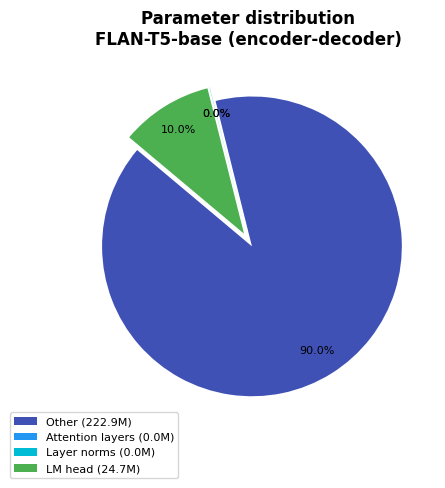

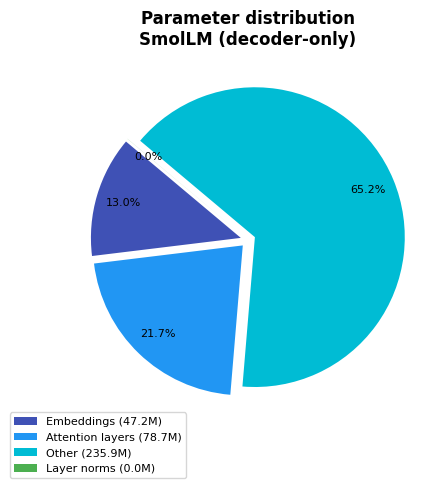

In [31]:
#  6.2  Pie chart of parameter distribution
def plot_param_pie(model, title):
    groups = {}
    for n, p in model.named_parameters():
        if   'embed' in n:                      key = 'Embeddings'
        elif 'attn' in n or 'attention' in n:   key = 'Attention layers'
        elif 'ff' in n or 'dense' in n:         key = 'Feed-forward layers'
        elif 'norm' in n or 'layer_norm' in n:  key = 'Layer norms'
        elif 'lm_head' in n:                    key = 'LM head'
        else:                                   key = 'Other'
        groups[key] = groups.get(key, 0) + p.numel()

    labels = list(groups.keys())
    sizes  = list(groups.values())
    colors = ['#3F51B5','#2196F3','#00BCD4','#4CAF50','#FF9800','#9C27B0']
    explode = [0.05] * len(labels)

    fig, ax = plt.subplots(figsize=(7, 5))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, autopct='%1.1f%%',
        colors=colors[:len(labels)], explode=explode,
        startangle=140, pctdistance=0.82
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.legend(wedges, [f"{l} ({s/1e6:.1f}M)" for l, s in zip(labels, sizes)],
              loc='lower left', fontsize=8, bbox_to_anchor=(-0.15, -0.15))
    ax.set_title(f'Parameter distribution\n{title}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_param_pie(flan_model, "FLAN-T5-base (encoder-decoder)")
plot_param_pie(smollm_model, "SmolLM (decoder-only)")

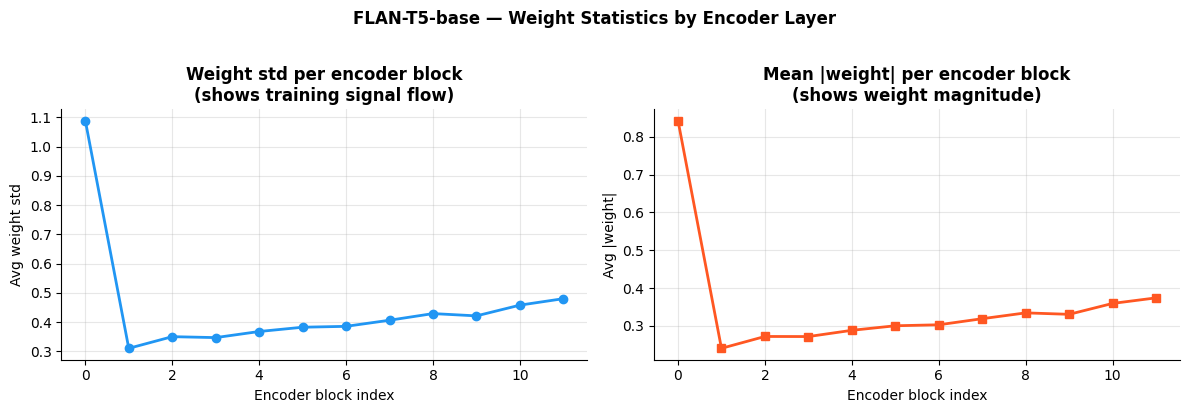

💡 In a well-trained model, weights tend to be small (no explosion)
   and roughly uniform across layers (no dying/saturating layers).


In [32]:
# 6.3  Layer-by-layer weight statistics
# Inspect the mean and std of weights in each encoder layer
# Healthy training → small, roughly normal distributions

layer_stats = []
for n, p in flan_model.named_parameters():
    if 'encoder.block' in n and 'weight' in n and 'layer_norm' not in n:
        # Extract block index
        parts = n.split('.')
        try:
            block_idx = int(parts[parts.index('block') + 1])
        except (ValueError, IndexError):
            continue
        w = p.detach().float()
        layer_stats.append({
            'block' : block_idx,
            'name'  : n.split('encoder.block.')[-1][:40],
            'mean'  : w.mean().item(),
            'std'   : w.std().item(),
            'abs_mean': w.abs().mean().item(),
        })

# Average by block
from collections import defaultdict
block_agg = defaultdict(lambda: {'stds': [], 'abs_means': []})
for s in layer_stats:
    block_agg[s['block']]['stds'].append(s['std'])
    block_agg[s['block']]['abs_means'].append(s['abs_mean'])

blocks   = sorted(block_agg.keys())
avg_stds = [np.mean(block_agg[b]['stds'])     for b in blocks]
avg_abs  = [np.mean(block_agg[b]['abs_means']) for b in blocks]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(blocks, avg_stds, 'o-', color='#2196F3', linewidth=2, markersize=6)
axes[0].set_title('Weight std per encoder block\n(shows training signal flow)', fontweight='bold')
axes[0].set_xlabel('Encoder block index')
axes[0].set_ylabel('Avg weight std')
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(blocks, avg_abs, 's-', color='#FF5722', linewidth=2, markersize=6)
axes[1].set_title('Mean |weight| per encoder block\n(shows weight magnitude)', fontweight='bold')
axes[1].set_xlabel('Encoder block index')
axes[1].set_ylabel('Avg |weight|')
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('FLAN-T5-base — Weight Statistics by Encoder Layer',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 In a well-trained model, weights tend to be small (no explosion)")
print("   and roughly uniform across layers (no dying/saturating layers).")

In [33]:
# 6.4  Visualise actual attention weights
# Run a forward pass and extract the attention matrices

sentence  = "Large language models learn from massive text corpora."
inputs    = flan_tok(sentence, return_tensors="pt")
token_labels_attn = [flan_tok.decode([t]) for t in inputs['input_ids'][0]]

with torch.no_grad():
    outputs = flan_model.encoder(
        input_ids      = inputs['input_ids'],
        attention_mask = inputs['attention_mask'],
        output_attentions=True
    )

# outputs.attentions: tuple of (batch, heads, seq, seq) for each layer
n_layers = len(outputs.attentions)
n_heads  = outputs.attentions[0].shape[1]
print(f"Encoder has {n_layers} layers × {n_heads} attention heads")
print(f"Sentence: '{sentence}'")
print(f"Tokens  : {token_labels_attn}")

Encoder has 12 layers × 12 attention heads
Sentence: 'Large language models learn from massive text corpora.'
Tokens  : ['Large', 'language', 'models', 'learn', 'from', 'massive', 'text', 'corp', 'or', 'a', '.', '</s>']


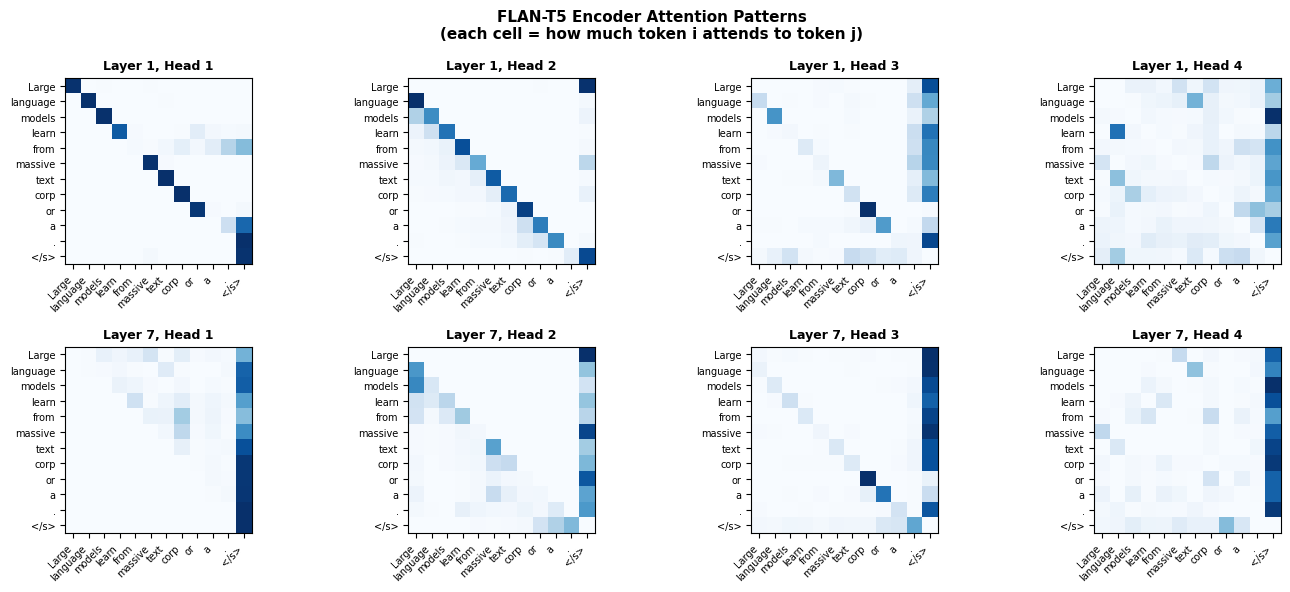


💡 Different heads specialise in different patterns:
   Some attend locally (diagonal), others to specific tokens (columns).
   Early layers capture syntax, later layers capture semantics.


In [34]:
# Plot attention patterns for 4 heads across 2 layers
layers_to_show = [0, n_layers // 2]   # first and middle layer
heads_to_show  = [0, 1, 2, 3]

fig, axes = plt.subplots(len(layers_to_show), len(heads_to_show),
                          figsize=(14, 6))

for row, layer_idx in enumerate(layers_to_show):
    attn = outputs.attentions[layer_idx][0]  # shape: (heads, seq, seq)
    for col, head_idx in enumerate(heads_to_show):
        ax  = axes[row][col]
        mat = attn[head_idx].numpy()
        im  = ax.imshow(mat, cmap='Blues', vmin=0, vmax=mat.max())
        ax.set_xticks(range(len(token_labels_attn)))
        ax.set_yticks(range(len(token_labels_attn)))
        ax.set_xticklabels(token_labels_attn, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(token_labels_attn, fontsize=7)
        ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=9, fontweight='bold')

fig.suptitle('FLAN-T5 Encoder Attention Patterns\n(each cell = how much token i attends to token j)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Different heads specialise in different patterns:")
print("   Some attend locally (diagonal), others to specific tokens (columns).")
print("   Early layers capture syntax, later layers capture semantics.")

### 🏋️ Exercise 6 — Find a Head That Attends to Punctuation

Change the `sentence` to one with commas, full stops, or question marks.  
Inspect the attention patterns — can you find a head that mostly attends to punctuation tokens?  
This is a real phenomenon called **punctuation heads** and was studied by researchers!

🚀 **Extension:** Compare attention patterns across the encoder layers for the same sentence. How do they differ between early and late layers?

In [ ]:
# YOUR CODE HERE
your_sentence = "Pre-training, fine-tuning, and alignment are three stages of LLM development."

inp    = flan_tok(your_sentence, return_tensors="pt")
toks   = [flan_tok.decode([t]) for t in inp['input_ids'][0]]

with torch.no_grad():
    out = flan_model.encoder(input_ids=inp['input_ids'],
                              attention_mask=inp['attention_mask'],
                              output_attentions=True)

# Plot ALL heads from layer 3 — look for the punctuation head!
layer_to_inspect = 3
attn_layer = out.attentions[layer_to_inspect][0].numpy()  # (heads, seq, seq)

fig, axes = plt.subplots(2, n_heads//2, figsize=(14, 6))
axes_flat = axes.flatten()
for h_idx in range(n_heads):
    ax  = axes_flat[h_idx]
    mat = attn_layer[h_idx]
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=mat.max())
    ax.set_xticks(range(len(toks)))
    ax.set_yticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(toks, fontsize=6)
    ax.set_title(f'Head {h_idx+1}', fontsize=8)

fig.suptitle(f'All heads — Layer {layer_to_inspect+1}\n"{your_sentence[:60]}..."',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# My observation:
# Head ??? seems to focus on punctuation because ...

---
## What We Built Today

| App | Core concept demonstrated |
|---|---|
| 🌡️ Temperature Lab | Sampling, randomness, creativity/coherence tradeoff |
| 🎭 Style Transfer | Instruction following, prompt engineering |
| 🐦 Persona Chatbot | System prompts, multi-turn context, instruction tuning |
| 📰 Headline Detector | Zero-shot classification, model limitations |
| 🎲 Text Adventure | Autoregressive generation, rolling context window |
| 🔬 Model Autopsy | Architecture internals, attention visualisation |

###  Where to go next

- **Run bigger models locally** → Install [Ollama](https://ollama.com/) and try `llama3`, `mistral`, or `qwen2`
- **HuggingFace Hub** → 500 000+ models at [huggingface.co](https://huggingface.co/models)
- **Open LLM Leaderboard** → Compare models: [huggingface.co/spaces/open-llm-leaderboard](https://huggingface.co/spaces/open-llm-leaderboard)
- **Prompt engineering guide** → [promptingguide.ai](https://www.promptingguide.ai) -- we will get back to this in next exercises!

---
*Advanced NLP · Exercise Session · SoSe 2026*